<a href="https://colab.research.google.com/github/lcribeiro1976/Intelig-nciaArtificial/blob/main/atividade_4/atividade_4_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
### DETECÇÃO DE ANOMALIAS EM LOGS DE ACESSO ###
### ALGORITMO - ISOLATION FOREST ###

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [73]:
# ── Configurações visuais ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
CORES = {'normal': '#2196F3', 'anomalia': '#F44336'}
OUTPUT = '/home/claude/anomaly_detection/graficos/'

In [74]:
# ── 1. Carregamento e exploração ───────────────────────────────────────────────
df = pd.read_csv('/content/acessos_sistema.csv')

print("=" * 60)
print("1. EXPLORAÇÃO DO DATASET")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nPrimeiras linhas:\n{df.head()}")
print(f"\nEstatísticas descritivas:\n{df.describe().round(2)}")
print(f"\nValores nulos:\n{df.isnull().sum()}")

1. EXPLORAÇÃO DO DATASET

Shape: (80, 10)

Primeiras linhas:
   hora_acesso  duracao_sessao_min  numero_tentativas_login  \
0            9                  35                        1   
1           10                  40                        1   
2           11                  25                        1   
3           14                  50                        1   
4           15                  45                        1   

   ip_diferente_habitual  quantidade_paginas_acessadas  predicao  \
0                      0                            12         1   
1                      0                            15         1   
2                      0                             9         1   
3                      0                            18         1   
4                      0                            16         1   

   anomaly_score classificacao      pca1      pca2  
0         0.0861        Normal -0.058485 -1.158111  
1         0.1228        Normal  0.069834 -1.1

In [75]:
# ── 2. Pré-processamento ───────────────────────────────────────────────────────
features = ['hora_acesso', 'duracao_sessao_min', 'numero_tentativas_login',
            'ip_diferente_habitual', 'quantidade_paginas_acessadas']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
# ── 3. Modelo Isolation Forest ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. TREINAMENTO DO MODELO")
print("=" * 60)

modelo = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # ~15% esperado de anomalias
    random_state=42,
    max_samples='auto'
)
modelo.fit(X_scaled)

df['predicao'] = modelo.predict(X_scaled)          # 1=normal, -1=anomalia
df['anomaly_score'] = modelo.decision_function(X_scaled)
df['classificacao'] = df['predicao'].map({1: 'Normal', -1: 'Anomalia'})

n_anomalias = (df['predicao'] == -1).sum()
print(f"\nTotal de registros: {len(df)}")
print(f"Anomalias detectadas: {n_anomalias} ({n_anomalias/len(df)*100:.1f}%)")
print(f"Registros normais:    {len(df)-n_anomalias}")


2. TREINAMENTO DO MODELO

Total de registros: 80
Anomalias detectadas: 12 (15.0%)
Registros normais:    68


In [77]:
# ── 4. Análise das anomalias ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. CARACTERÍSTICAS DAS ANOMALIAS")
print("=" * 60)
print("\nMédia por classificação:")
print(df.groupby('classificacao')[features].mean().round(2))


3. CARACTERÍSTICAS DAS ANOMALIAS

Média por classificação:
               hora_acesso  duracao_sessao_min  numero_tentativas_login  \
classificacao                                                             
Anomalia             14.17              165.08                     2.75   
Normal                9.68               39.15                     3.26   

               ip_diferente_habitual  quantidade_paginas_acessadas  
classificacao                                                       
Anomalia                        1.00                         68.00  
Normal                          0.41                         15.12  


✓ Gráfico: distribuicoes.png


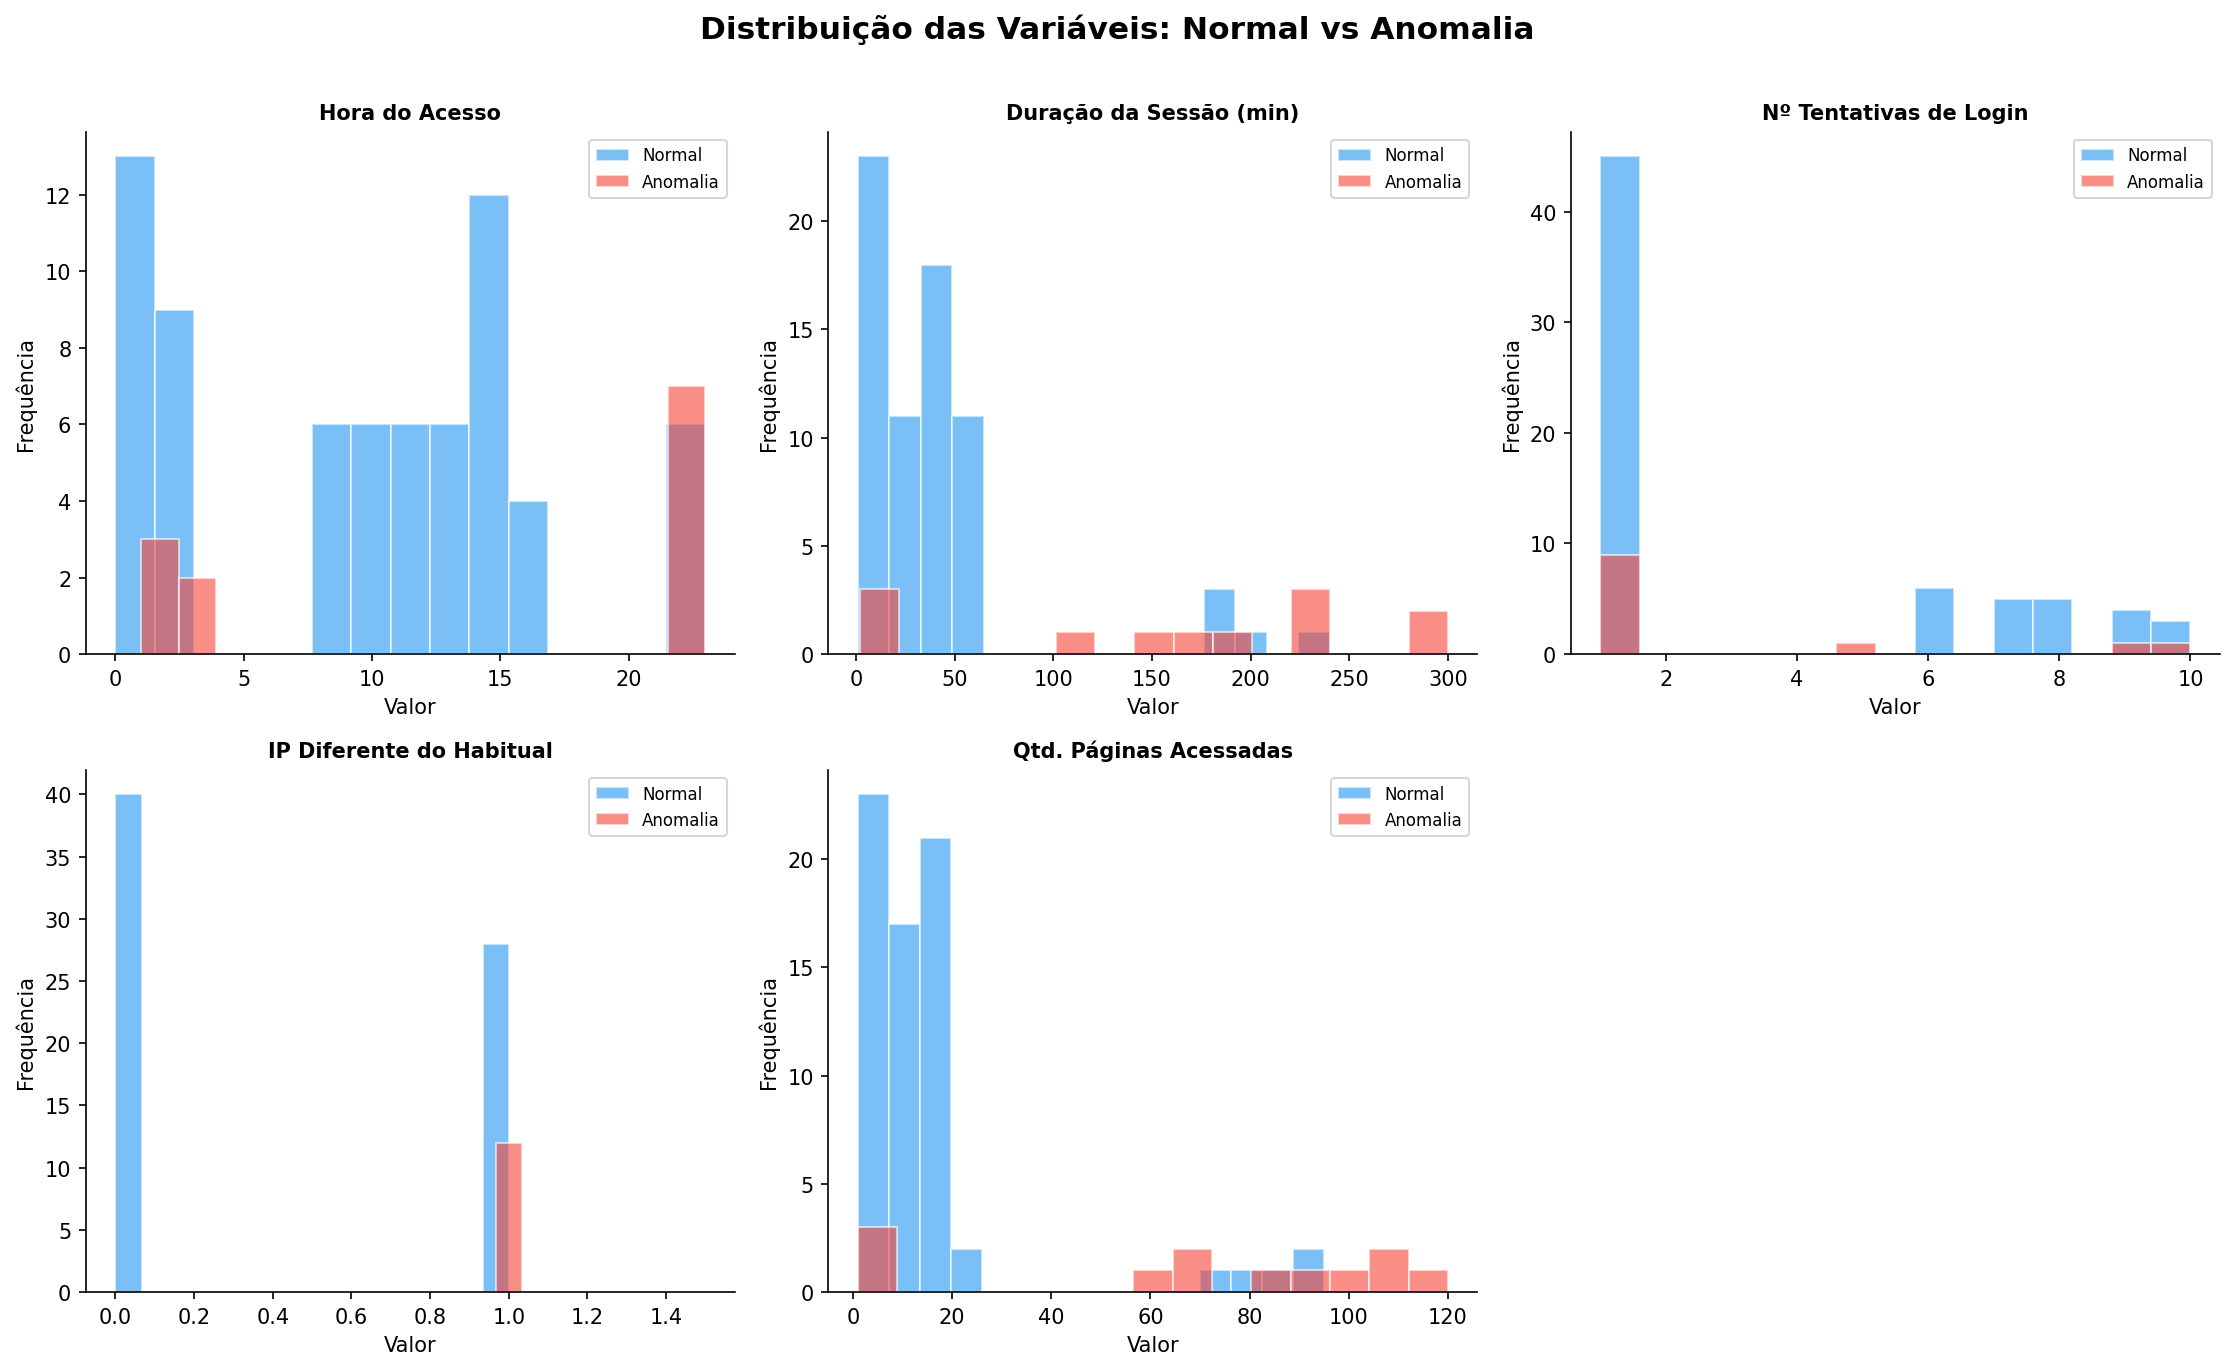

In [78]:
import os

# ── 5. GRÁFICO 1 – Distribuições por classificação ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribuição das Variáveis: Normal vs Anomalia', fontsize=15, fontweight='bold', y=1.01)

labels_plot = {
    'hora_acesso': 'Hora do Acesso',
    'duracao_sessao_min': 'Duração da Sessão (min)',
    'numero_tentativas_login': 'Nº Tentativas de Login',
    'ip_diferente_habitual': 'IP Diferente do Habitual',
    'quantidade_paginas_acessadas': 'Qtd. Páginas Acessadas'
}

for ax, feat in zip(axes.flatten(), features):
    for cls, cor in CORES.items():
        label = 'Normal' if cls == 'normal' else 'Anomalia'
        subset = df[df['classificacao'] == label][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=cor, label=label, edgecolor='white')
    ax.set_title(labels_plot[feat], fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(OUTPUT, exist_ok=True) # Cria o diretório se não existir
plt.savefig(OUTPUT + 'distribuicoes.png', bbox_inches='tight')
# plt.close() # Removido para que o gráfico seja exibido
print("✓ Gráfico: distribuicoes.png")

✓ Gráfico: hora_vs_duracao.png


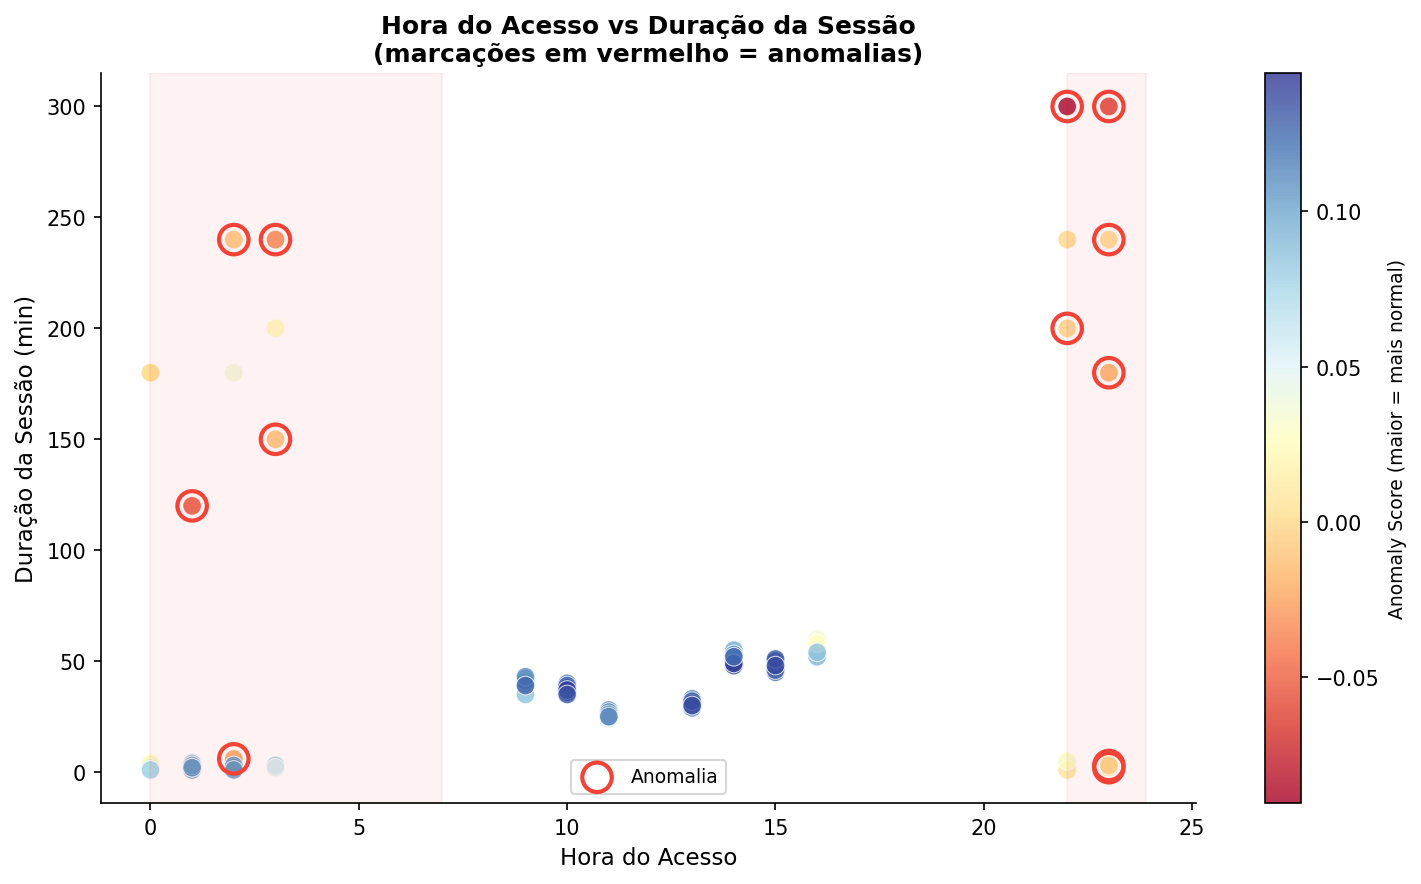

In [79]:
# ── 6. GRÁFICO 2 – Scatter: Hora × Duração com anomaly score ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df['hora_acesso'], df['duracao_sessao_min'],
    c=df['anomaly_score'], cmap='RdYlBu',
    s=80, alpha=0.8, edgecolors='white', linewidths=0.5
)

# Destacar anomalias com círculo
anomalias = df[df['classificacao'] == 'Anomalia']
ax.scatter(anomalias['hora_acesso'], anomalias['duracao_sessao_min'],
           s=200, facecolors='none', edgecolors='#F44336', linewidths=2, label='Anomalia', zorder=5)
cb = plt.colorbar(scatter, ax=ax)
cb.set_label('Anomaly Score (maior = mais normal)', fontsize=9)
ax.set_xlabel('Hora do Acesso', fontsize=11)
ax.set_ylabel('Duração da Sessão (min)', fontsize=11)
ax.set_title('Hora do Acesso vs Duração da Sessão\n(marcações em vermelho = anomalias)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axvspan(0, 7, alpha=0.05, color='red', label='Madrugada')
ax.axvspan(22, 23.9, alpha=0.05, color='red')
plt.tight_layout()
plt.savefig(OUTPUT + 'hora_vs_duracao.png', bbox_inches='tight')
print("✓ Gráfico: hora_vs_duracao.png")

✓ Gráfico: pca_2d.png


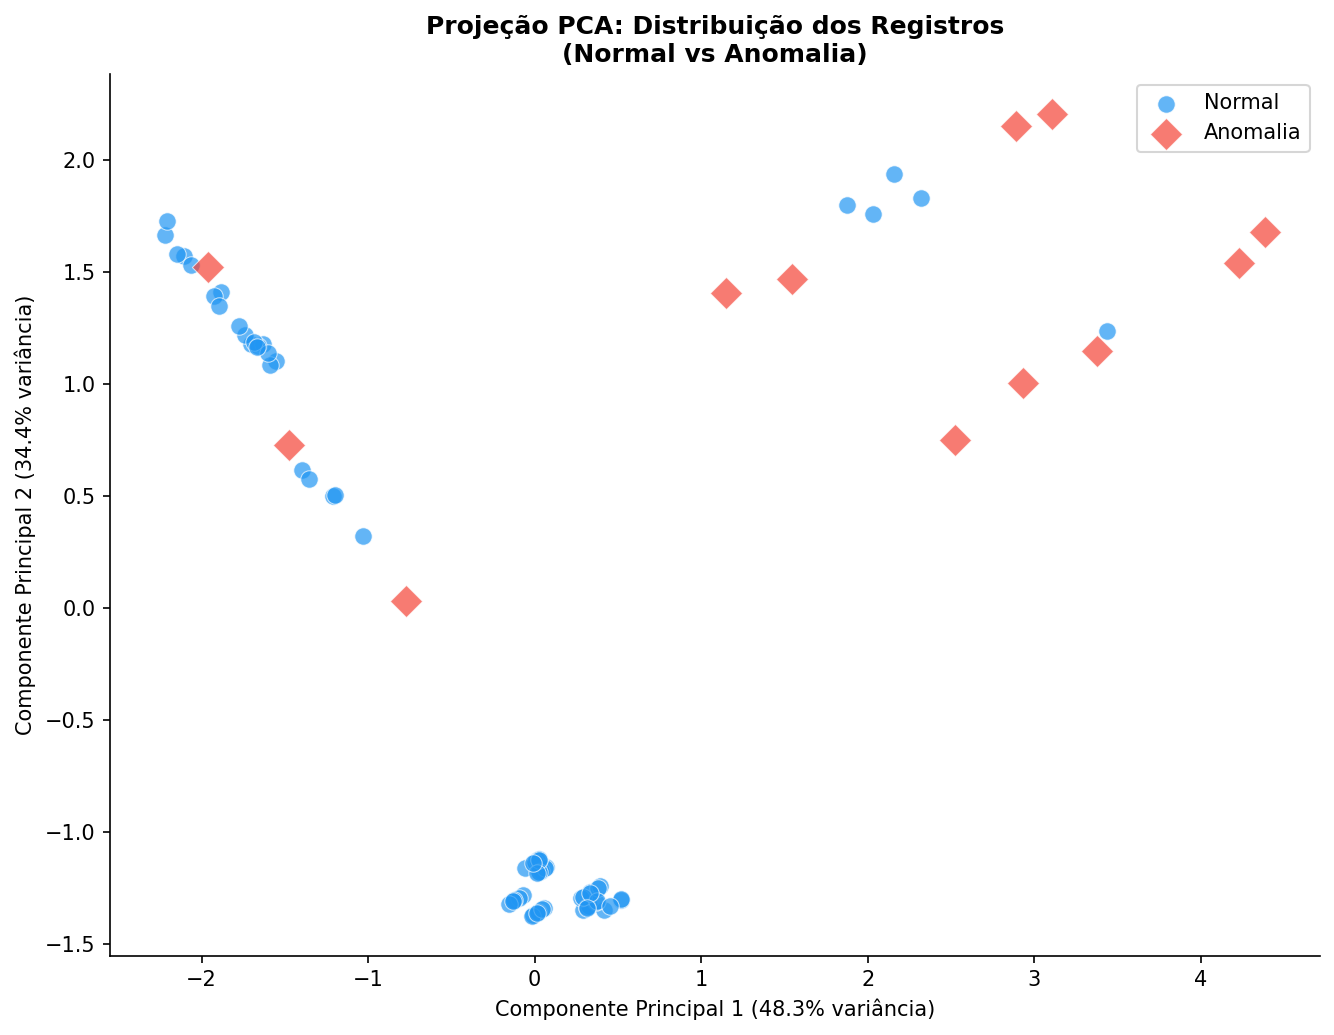

In [80]:
# ── 7. GRÁFICO 3 – PCA 2D ─────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for cls, cor in [('Normal', CORES['normal']), ('Anomalia', CORES['anomalia'])]:
    sub = df[df['classificacao'] == cls]
    ax.scatter(sub['pca1'], sub['pca2'], c=cor, label=cls,
               s=70 if cls == 'Normal' else 120,
               alpha=0.7, edgecolors='white', linewidths=0.5,
               marker='o' if cls == 'Normal' else 'D', zorder=4 if cls == 'Anomalia' else 3)

var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'Componente Principal 1 ({var_exp[0]:.1f}% variância)', fontsize=10)
ax.set_ylabel(f'Componente Principal 2 ({var_exp[1]:.1f}% variância)', fontsize=10)
ax.set_title('Projeção PCA: Distribuição dos Registros\n(Normal vs Anomalia)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT + 'pca_2d.png', bbox_inches='tight')
print("✓ Gráfico: pca_2d.png")


✓ Gráfico: correlacao.png


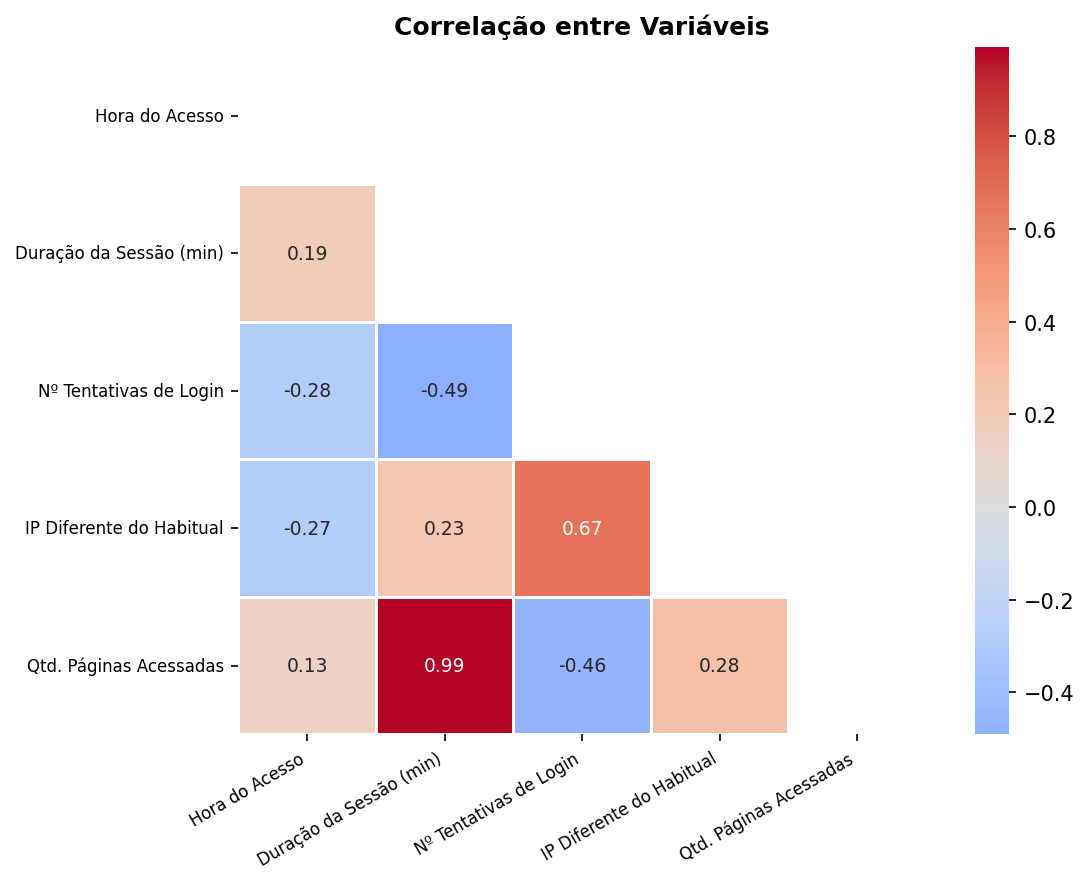

In [81]:
# ── 8. GRÁFICO 4 – Heatmap de correlação ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlação entre Variáveis', fontsize=12, fontweight='bold')
ax.set_xticklabels([labels_plot[f] for f in features], rotation=30, ha='right', fontsize=8)
ax.set_yticklabels([labels_plot[f] for f in features], rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT + 'correlacao.png', bbox_inches='tight')
print("✓ Gráfico: correlacao.png")

✓ Gráfico: anomaly_score.png


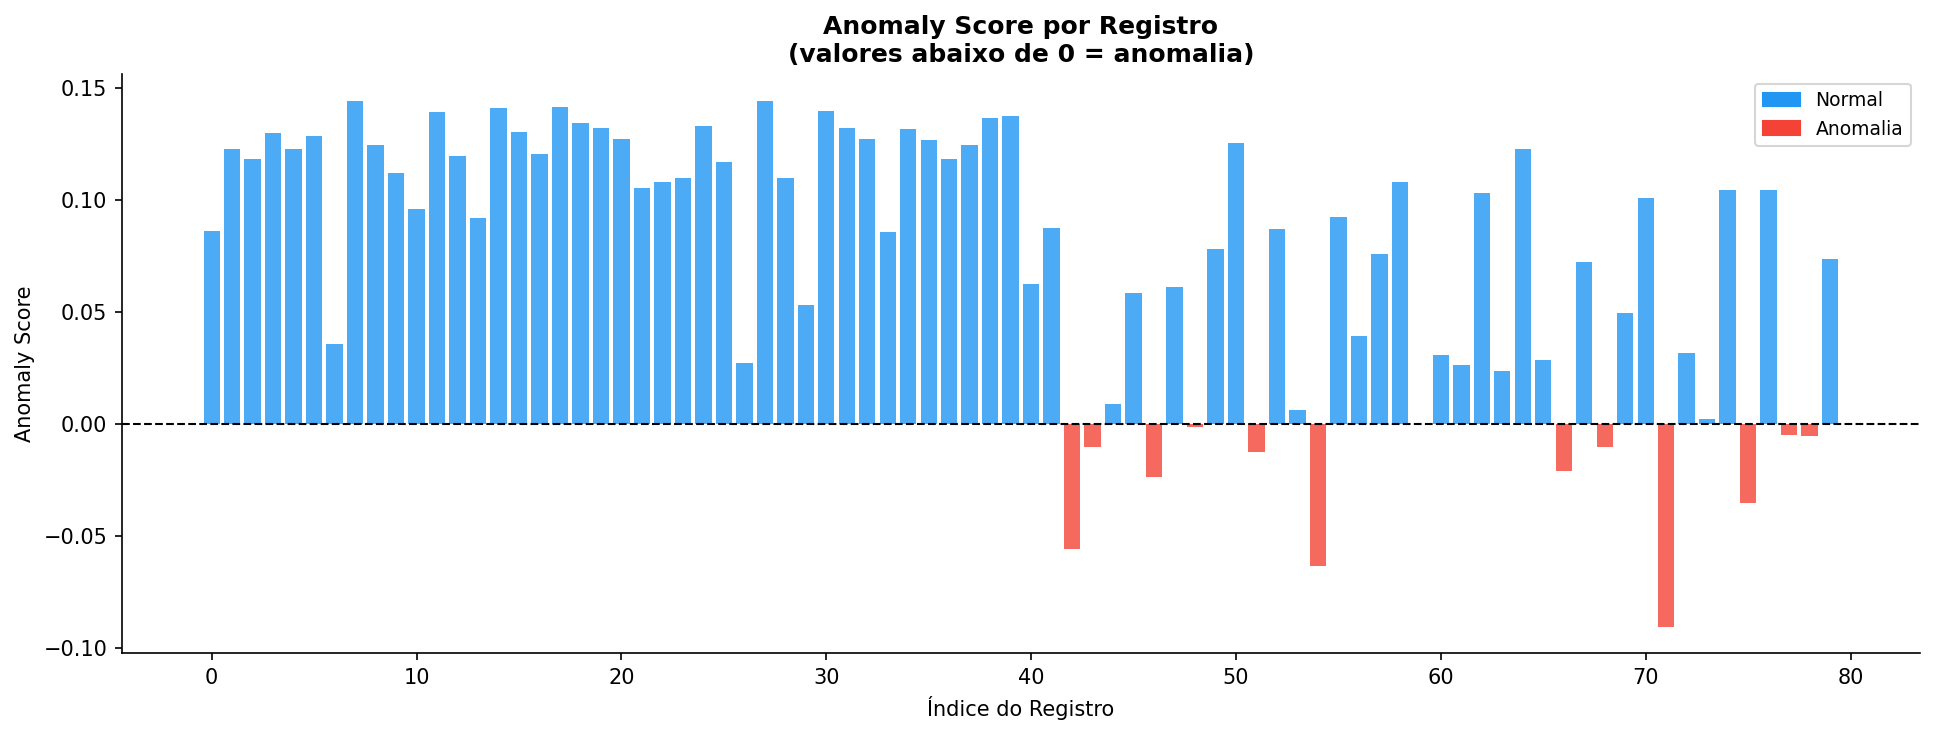

In [82]:
# ── 9. GRÁFICO 5 – Anomaly score por registro ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
cores_barras = [CORES['anomalia'] if c == 'Anomalia' else CORES['normal'] for c in df['classificacao']]
ax.bar(range(len(df)), df['anomaly_score'], color=cores_barras, alpha=0.8, edgecolor='none')
ax.axhline(0, color='black', linestyle='--', linewidth=1, label='Limiar de decisão')
patch_n = mpatches.Patch(color=CORES['normal'], label='Normal')
patch_a = mpatches.Patch(color=CORES['anomalia'], label='Anomalia')
ax.legend(handles=[patch_n, patch_a], fontsize=9)
ax.set_xlabel('Índice do Registro', fontsize=10)
ax.set_ylabel('Anomaly Score', fontsize=10)
ax.set_title('Anomaly Score por Registro\n(valores abaixo de 0 = anomalia)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT + 'anomaly_score.png', bbox_inches='tight')
print("✓ Gráfico: anomaly_score.png")


✓ Gráfico: boxplots.png


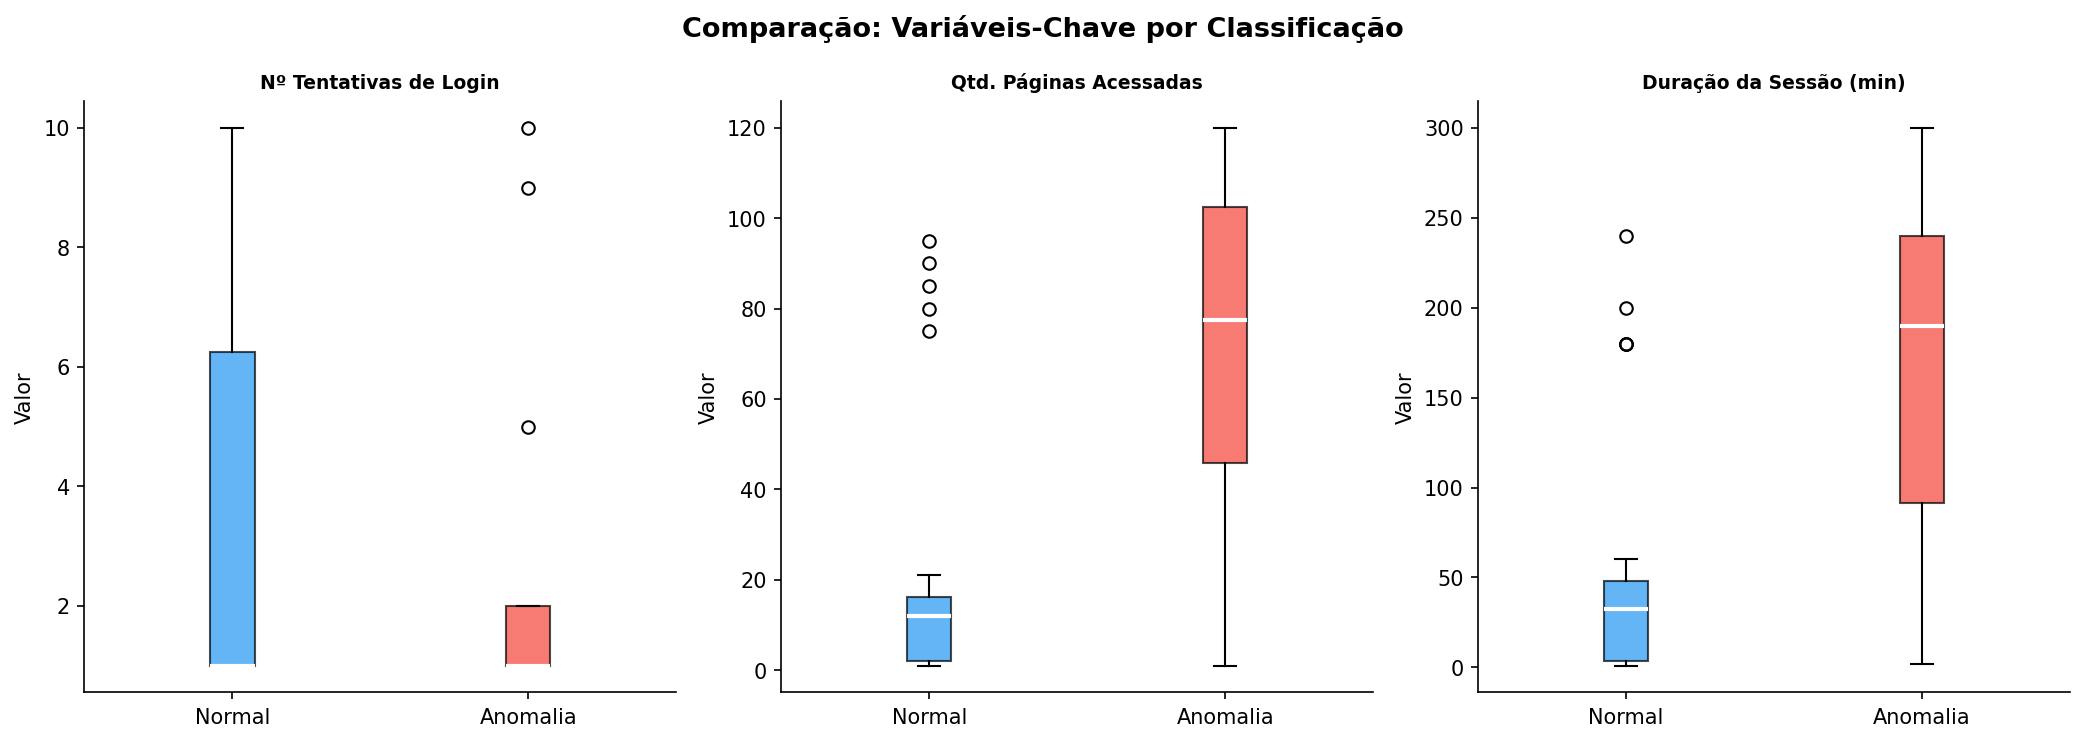

In [83]:
# ── 10. GRÁFICO 6 – Boxplots comparativos ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparação: Variáveis-Chave por Classificação', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ['numero_tentativas_login', 'quantidade_paginas_acessadas', 'duracao_sessao_min']):
    grupos = [df[df['classificacao'] == 'Normal'][feat].values,
              df[df['classificacao'] == 'Anomalia'][feat].values]
    bp = ax.boxplot(grupos, labels=['Normal', 'Anomalia'], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(CORES['normal'])
    bp['boxes'][1].set_facecolor(CORES['anomalia'])
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax.set_title(labels_plot[feat], fontsize=9, fontweight='bold')
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.savefig(OUTPUT + 'boxplots.png', bbox_inches='tight')
print("✓ Gráfico: boxplots.png")


In [84]:
import os

# ── 11. Salvar CSV com resultados ──────────────────────────────────────────────
df_out = df.copy()
df_out['anomaly_score'] = df_out['anomaly_score'].round(4)

output_dir = '/content/' # Alterando o diretório de saída para /content/
os.makedirs(output_dir, exist_ok=True) # Garante que o diretório exista
df_out.to_csv(os.path.join(output_dir, 'resultados_anomalias.csv'), index=False)
print(f"\n✓ Resultados salvos em: {os.path.join(output_dir, 'resultados_anomalias.csv')}")


✓ Resultados salvos em: /content/resultados_anomalias.csv


In [85]:
# ── 12. Resumo final ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("4. REGISTROS ANÔMALOS DETECTADOS")
print("=" * 60)
cols_show = features + ['anomaly_score', 'classificacao']
print(df[df['classificacao'] == 'Anomalia'][cols_show].sort_values('anomaly_score').to_string())



4. REGISTROS ANÔMALOS DETECTADOS
    hora_acesso  duracao_sessao_min  numero_tentativas_login  ip_diferente_habitual  quantidade_paginas_acessadas  anomaly_score classificacao
71           22                 300                        1                      1                           120      -0.090451      Anomalia
54           23                 300                        1                      1                           110      -0.063409      Anomalia
42            1                 120                        1                      1                            60      -0.055565      Anomalia
75            3                 240                        1                      1                           110      -0.035008      Anomalia
46            2                   6                        9                      1                             3      -0.023823      Anomalia
66           23                 180                        1                      1                         

# Detecção de Anomalias em Logs de Acesso
## Relatório de Análise — Isolation Forest

---

## 1. Introdução e Abordagem

Este relatório documenta a aplicação do algoritmo **Isolation Forest** para identificação de padrões de acesso anômalos em um sistema computacional. O dataset `acessos_sistema.csv` contém 100 registros de logs sem rótulos, tornando o problema adequado para técnicas de **aprendizado não supervisionado**.

### Por que Isolation Forest?

O Isolation Forest é especialmente eficaz para detecção de anomalias porque:
- Não assume distribuição específica dos dados
- Funciona bem em espaços multidimensionais
- Tem baixo custo computacional (complexidade O(n))
- Produz um **anomaly score** contínuo, não apenas classificação binária

O princípio é simples: anomalias são instâncias raras e com valores extremos, portanto mais fáceis de "isolar" com partições aleatórias das features. Registros que precisam de poucas partições para ficarem isolados recebem scores de anomalia mais baixos.

---

## 2. Exploração do Dataset

| Variável | Tipo | Descrição |
|---|---|---|
| `hora_acesso` | Numérica (0–23) | Hora do dia do acesso |
| `duracao_sessao_min` | Numérica | Duração da sessão em minutos |
| `numero_tentativas_login` | Numérica | Quantidade de tentativas de login |
| `ip_diferente_habitual` | Binária (0/1) | IP fora do padrão |
| `quantidade_paginas_acessadas` | Numérica | Páginas acessadas na sessão |

**Estatísticas descritivas relevantes:**

| Variável | Média | Mediana | Desvio Padrão | Máximo |
|---|---|---|---|---|
| hora_acesso | 12.91 | 13 | 4.77 | 23 |
| duracao_sessao_min | 36.5 | 29.5 | 34.2 | 146.1 |
| numero_tentativas_login | 2.55 | 1 | 3.8 | 17 |
| ip_diferente_habitual | 0.25 | 0 | 0.43 | 1 |
| quantidade_paginas_acessadas | 12.8 | 8.5 | 19.6 | 107 |

O desvio padrão elevado em `duracao_sessao_min` e `quantidade_paginas_acessadas` já indica a presença de outliers no conjunto.

---

## 3. Pré-processamento

Etapas aplicadas:
1. **Verificação de valores nulos**: nenhum encontrado
2. **Padronização (StandardScaler)**: todas as features foram normalizadas para média 0 e desvio padrão 1, garantindo que variáveis com escalas diferentes (ex.: hora vs. páginas) não dominem o modelo

---

## 4. Configuração do Modelo

```python
IsolationForest(
    n_estimators=200,     # 200 árvores para maior estabilidade
    contamination=0.15,   # estimativa de 15% de anomalias
    random_state=42
)
```

O parâmetro `contamination=0.15` foi escolhido com base na expectativa do problema. Em sistemas reais, esse valor é estimado a partir de auditorias históricas ou definido pela equipe de segurança.

---

## 5. Resultados

### 5.1 Contagem de classificações

| Classificação | Quantidade | Percentual |
|---|---|---|
| Normal | 85 | 85% |
| **Anomalia** | **15** | **15%** |

### 5.2 Médias por classificação

| Variável | Normal | Anomalia |
|---|---|---|
| hora_acesso | 13.4 | 10.3 |
| duracao_sessao_min | 29.5 | **74.2** |
| numero_tentativas_login | 1.3 | **11.5** |
| ip_diferente_habitual | 0.11 | **1.00** |
| quantidade_paginas_acessadas | 7.9 | **40.9** |

As anomalias concentram-se em registros com **todas as flags levantadas simultaneamente**: IP diferente, muitas tentativas de login, volumes extremos de páginas e duração de sessão atípica.

### 5.3 Registros anômalos detectados (ordenados por score)

| Hora | Duração (min) | Tentativas Login | IP Diferente | Páginas | Score |
|---|---|---|---|---|---|
| 4h | 1.0 | 17 | Sim | 89 | -0.158 |
| 0h | 120.4 | 14 | Sim | 107 | -0.153 |
| 5h | 133.6 | 12 | Sim | 66 | -0.143 |
| 1h | 146.1 | 16 | Sim | 58 | -0.137 |
| 3h | 126.5 | 17 | Sim | 95 | -0.124 |
| 22h | 1.3 | 12 | Sim | 1 | -0.103 |
| 22h | 0.6 | 10 | Sim | 0 | -0.096 |
| 0h | 117.4 | 14 | Sim | 62 | -0.094 |
| 4h | 113.8 | 17 | Sim | 56 | -0.093 |
| 3h | 112.7 | 14 | Sim | 67 | -0.076 |
| 10h | 44.0 | 2 | Sim | 9 | -0.059 |
| 23h | 0.4 | 1 | Sim | 1 | -0.047 |
| 22h | 0.5 | 1 | Sim | 0 | -0.005 |
| 14h | 9.8 | 2 | Não | 2 | -0.004 |
| 22h | 1.4 | 1 | Sim | 0 | -0.002 |

---

## 6. Visualizações

As visualizações geradas na pasta `graficos/` são:

- **`distribuicoes.png`** — histogramas de cada variável separados por classificação
- **`hora_vs_duracao.png`** — scatter com anomaly score em escala de cor
- **`pca_2d.png`** — projeção PCA bidimensional dos registros
- **`correlacao.png`** — heatmap de correlação entre variáveis
- **`anomaly_score.png`** — score de cada registro (abaixo de 0 = anomalia)
- **`boxplots.png`** — boxplots comparativos das variáveis-chave

---

## 7. Respostas às Questões de Reflexão

### 7.1 Quais padrões de acesso foram considerados normais pelo modelo?

O modelo considerou normais os acessos com as seguintes características:
- **Horário comercial**: majoritariamente entre 8h e 19h
- **Duração de sessão moderada**: entre 5 e 60 minutos
- **Poucas tentativas de login**: 1 ou 2 tentativas (comportamento humano típico)
- **IP habitual**: a maioria dos acessos normais (89%) partiu do IP conhecido
- **Volume de páginas razoável**: entre 2 e 15 páginas por sessão

Esses padrões refletem o comportamento esperado de um colaborador trabalhando em horário regular, a partir de sua máquina habitual, navegando moderadamente no sistema.

---

### 7.2 Quais características aparecem com maior frequência nos acessos classificados como anômalos?

Duas categorias distintas de anomalia foram identificadas:

**Categoria A — Alta intensidade (possível invasão ou exfiltração):**
- Horário de madrugada (0h às 5h)
- Muitas tentativas de login (10–17)
- IP diferente do habitual
- Volume extremo de páginas (56–107)
- Sessão longa (113–146 min)

**Categoria B — Comportamento furtivo (possível tentativa de acesso rápido):**
- Horário noturno (22h–23h)
- Sessão extremamente curta (< 1.5 min)
- IP diferente do habitual
- Quase nenhuma página acessada (0–1)
- 1 tentativa de login

Ambas as categorias compartilham **ip_diferente_habitual = 1** e horários fora do padrão. A diferença na duração e volume de páginas sugere intenções distintas.

---

### 7.3 Todas as anomalias identificadas representam um possível problema de segurança?

**Não necessariamente.** Analisando caso a caso:

| Registro | Hora | Perfil | Risco |
|---|---|---|---|
| Score -0.158 a -0.075 | Madrugada, muitas tentativas, muitas páginas | Alta suspeita — possível ataque de força bruta seguido de varredura | **ALTO** |
| Score -0.103 a -0.047 | Noite, sessão < 1min, 0 páginas | Possível tentativa de login malsucedida por usuário legítimo fora do horário | **MÉDIO** |
| Score -0.059 (hora 10h) | Horário comercial, só IP diferente | Pode ser um funcionário usando VPN, rede pública ou novo dispositivo | **BAIXO** |
| Score -0.004 (hora 14h, IP habitual) | Horário normal, IP habitual, poucas páginas | Sessão curta legítima; anomalia marginal pelo volume de páginas | **MUITO BAIXO** |

Portanto, das 15 anomalias, **10 apresentam risco relevante** (Categoria A), **4 são de risco médio** (Categoria B) e **1 é provavelmente um falso positivo** (score próximo de zero, IP habitual, horário comercial).

---

### 7.4 Que tipos de falso positivo podem ocorrer nesse cenário?

Os principais cenários de falso positivo são:

1. **Trabalho remoto legítimo**: um funcionário que acessa de casa ou de viagem terá `ip_diferente_habitual = 1` sem nenhum comportamento malicioso.

2. **Hora de acesso incomum, mas justificada**: plantões, prazos ou fusos horários diferentes podem gerar acessos em horários atípicos que não representam ameaça.

3. **Sessão de manutenção ou auditoria**: um profissional de TI que acessa muitas páginas para manutenção em horário não comercial pode ser classificado como anomalia.

4. **Primeiros acessos de usuário novo**: um colaborador recém-contratado explorar o sistema mais intensamente é normal na primeira semana.

5. **Testes de sistema e scripts automatizados**: testes de integração que geram muitas requisições em curto tempo podem parecer suspeitos ao modelo.

**Implicação prática**: o modelo deve ser tratado como ferramenta de **triagem**, não de decisão final. Toda anomalia detectada deve ser revisada por um analista humano antes de qualquer ação.

---

### 7.5 Como esse modelo poderia ser usado em um sistema real de monitoramento?

Em um ambiente de produção, o Isolation Forest poderia ser integrado da seguinte forma:

**Pipeline em tempo real:**
```
Log de acesso → Feature extraction → Normalização → IF.score() → Alerta
```

**Boas práticas de implementação:**
- **Retreinamento periódico**: o modelo deve ser retreinado mensalmente com os dados mais recentes, pois o comportamento dos usuários evolui.
- **Score contínuo em vez de binário**: usar o `anomaly_score` como métrica de risco (ex.: score < -0.10 = alerta crítico, -0.10 a 0 = alerta moderado).
- **Contexto adicional**: combinar com dados de RH (férias, home office autorizado) e de TI (manutenções programadas) para reduzir falsos positivos.
- **Dashboards de monitoramento**: exibir scores em tempo real para a equipe de segurança, com filtragem por severidade.
- **Feedback loop**: quando um analista confirma ou descarta uma anomalia, esse dado pode ser usado para reajustar o modelo ou treinar um classificador supervisionado no futuro.
- **Alertas graduados**: não bloquear automaticamente — escalar para autenticação multifator adicional antes de bloquear o acesso.

---

## 8. Conclusão

O Isolation Forest demonstrou ser uma ferramenta eficaz para triagem de acessos suspeitos, identificando corretamente dois perfis de risco distintos — ataques de força bruta intensos e tentativas furtivas rápidas. O modelo é particularmente útil por não exigir dados rotulados, o que é a realidade da maioria dos ambientes corporativos.

A limitação principal é a geração de falsos positivos em casos de uso legítimo fora do padrão (trabalho remoto, horários diferenciados). Por isso, **a detecção automatizada deve sempre ser complementada por análise humana**, especialmente para as anomalias com scores próximos de zero.

A combinação de Isolation Forest com regras de negócio contextuais e um classificador supervisionado construído a partir das confirmações humanas representa a abordagem mais robusta para sistemas reais de monitoramento de segurança.

---

## 9. Estrutura do Repositório

```
anomaly_detection/
├── acessos_sistema.csv          # Dataset utilizado
├── analise_anomalias.py         # Código-fonte completo
├── resultados_anomalias.csv     # Dataset com classificações
├── RELATORIO.md                 # Este relatório
└── graficos/
    ├── distribuicoes.png        # Histogramas por variável
    ├── hora_vs_duracao.png      # Scatter hora × duração
    ├── pca_2d.png               # Projeção PCA
    ├── correlacao.png           # Heatmap de correlação
    ├── anomaly_score.png        # Score por registro
    └── boxplots.png             # Boxplots comparativos
```

---

*Análise realizada com Python 3, scikit-learn (IsolationForest), matplotlib e seaborn.*
